## **Data Understanding**

The dataset contains information about 10,000 movies released between 1902 and 2022. It includes details such as movie titles, genres, original languages, descriptions, popularity, release dates, average ratings, and vote counts. The dataset contains 9 features and has very few missing values.

The variables include id, which represents the unique movie identifier; title, which contains the movie name; genre, which describes the movie category; original_language, which represents the language of the movie; and overview, which provides a short description of the movie. The numerical features include popularity, vote_average, and vote_count. The feature release_date represents the date when the movie was released.

The dataset does not contain a predefined class variable. However, vote_average can be used as the response variable for predicting movie ratings. In this case, the problem can be treated as a regression task, and evaluation metrics such as MAE, RMSE can be used to measure model performance. The dataset can also be used for movie recommendation, genre classification, popularity prediction, and NLP analysis.

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

## **Data Explore**

In [2]:
movies = pd.read_csv("dataset.csv")

In [3]:
movies.head()

,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,9/23/1994,8.7,21862
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,10/19/1995,8.7,3731
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,3/14/1972,8.7,16280
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,12/15/1993,8.6,12959
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,12/20/1974,8.6,9811


In [4]:
movies.columns

Index(['id', 'title', 'genre', 'original_language', 'overview', 'popularity',
       'release_date', 'vote_average', 'vote_count'],
      dtype='object')

In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   title              10000 non-null  object 
 2   genre              9997 non-null   object 
 3   original_language  10000 non-null  object 
 4   overview           9987 non-null   object 
 5   popularity         10000 non-null  float64
 6   release_date       10000 non-null  object 
 7   vote_average       10000 non-null  float64
 8   vote_count         10000 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 703.2+ KB


## **Exploratory Data Analysis (EDA)**

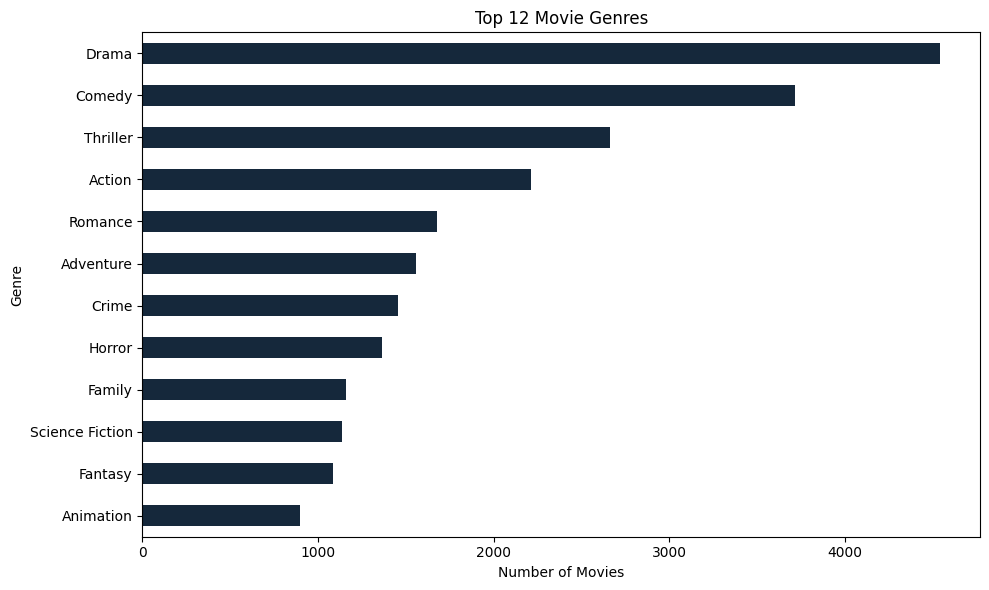

In [ ]:
genre_counts = movies["genre"].dropna().str.split(",").explode().str.strip().value_counts().head(12)

fig, ax = plt.subplots(figsize=(10,6))
genre_counts.sort_values().plot(kind="barh",ax=ax,color="#15283B")
ax.set_title("Top 12 Movie Genres")
ax.set_xlabel("Number of Movies")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()

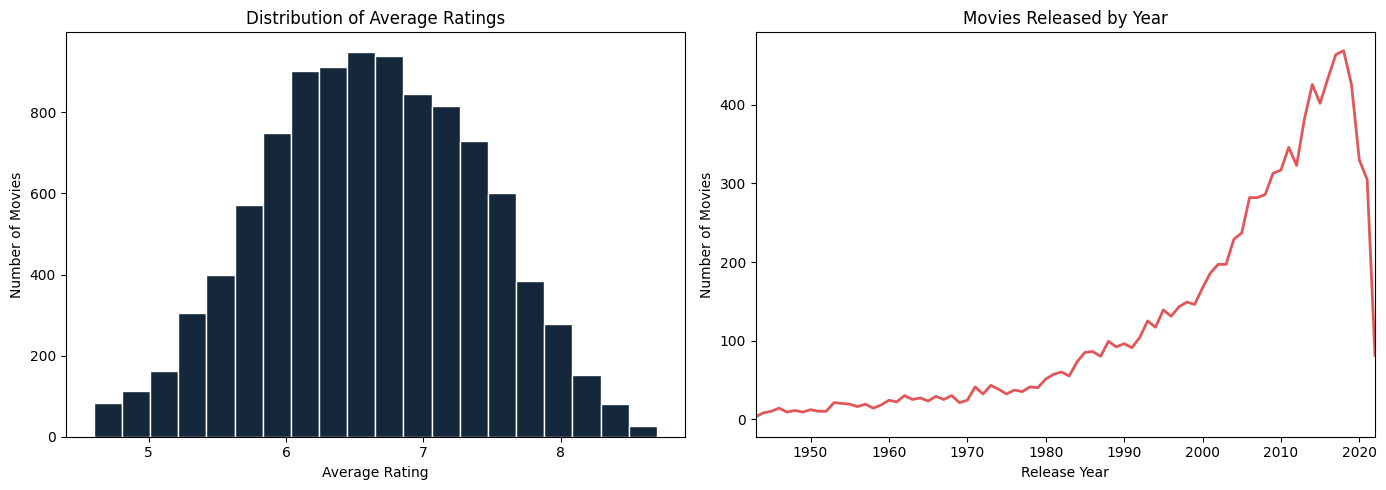

In [7]:
release_year = pd.to_datetime(movies["release_date"], errors="coerce").dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(movies["vote_average"].dropna(), bins=20, color="#15283B", edgecolor="white")
axes[0].set_title("Distribution of Average Ratings")
axes[0].set_xlabel("Average Rating")
axes[0].set_ylabel("Number of Movies")

release_year.dropna().astype(int).value_counts().sort_index().plot(ax=axes[1], color="#E15759", linewidth=2)
axes[1].set_title("Movies Released by Year")
axes[1].set_xlabel("Release Year")
axes[1].set_ylabel("Number of Movies")
axes[1].set_xlim(release_year.quantile(0.01), release_year.max())
plt.tight_layout()
plt.show()

## **Data Handling & Preprocessing**

In [8]:
movies ["tags"] = movies["genre"] + movies["overview"]

In [9]:
movies.head()

,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count,tags
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,9/23/1994,8.7,21862,"Drama,CrimeFramed in the 1940s for the double ..."
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,10/19/1995,8.7,3731,"Comedy,Drama,RomanceRaj is a rich, carefree, h..."
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,3/14/1972,8.7,16280,"Drama,CrimeSpanning the years 1945 to 1955, a ..."
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,12/15/1993,8.6,12959,"Drama,History,WarThe true story of how busines..."
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,12/20/1974,8.6,9811,"Drama,CrimeIn the continuing saga of the Corle..."


In [10]:
new_df = movies[["id","title","genre","overview","tags"]]

In [11]:
new_df = new_df.drop(columns=['genre','overview'])

In [12]:
new_df.head()

,id,title,tags
0,278,The Shawshank Redemption,"Drama,CrimeFramed in the 1940s for the double ..."
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,RomanceRaj is a rich, carefree, h..."
2,238,The Godfather,"Drama,CrimeSpanning the years 1945 to 1955, a ..."
3,424,Schindler's List,"Drama,History,WarThe true story of how busines..."
4,240,The Godfather: Part II,"Drama,CrimeIn the continuing saga of the Corle..."


## **Feature Extraction**

In [13]:
cv = CountVectorizer(max_features=10000,stop_words='english')

In [14]:
cv

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [15]:
vec = cv.fit_transform(new_df["tags"].values.astype('U')).toarray()

In [16]:
vec

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(10000, 10000))

In [17]:
vec.shape

(10000, 10000)

## **Cosine Similarity**

In [18]:
sim = cosine_similarity(vec)

In [19]:
sim

array([[1.        , 0.06253054, 0.05802589, ..., 0.07963978, 0.07597372,
        0.03798686],
       [0.06253054, 1.        , 0.08980265, ..., 0.        , 0.        ,
        0.        ],
       [0.05802589, 0.08980265, 1.        , ..., 0.02541643, 0.03636965,
        0.        ],
       ...,
       [0.07963978, 0.        , 0.02541643, ..., 1.        , 0.03327792,
        0.03327792],
       [0.07597372, 0.        , 0.03636965, ..., 0.03327792, 1.        ,
        0.04761905],
       [0.03798686, 0.        , 0.        , ..., 0.03327792, 0.04761905,
        1.        ]], shape=(10000, 10000))

## **Recommendation Analysis**

In [20]:
new_df[new_df['title']== 'The Shawshank Redemption']

,id,title,tags
0,278,The Shawshank Redemption,"Drama,CrimeFramed in the 1940s for the double ..."


In [21]:
dist = sorted(list(enumerate(sim[0])),reverse=True,key=lambda vec:vec[1])

In [22]:
dist

[(0, np.float64(0.9999999999999998)),
 (3709, np.float64(0.23539595453459988)),
 (3649, np.float64(0.22019275302527214)),
 (9006, np.float64(0.20751433915982243)),
 (2605, np.float64(0.20100756305184245)),
 (4068, np.float64(0.20100756305184245)),
 (6156, np.float64(0.20100756305184245)),
 (698, np.float64(0.19894589252079753)),
 (7324, np.float64(0.19767387315371682)),
 (1009, np.float64(0.19069251784911848)),
 (884, np.float64(0.1899342940993966)),
 (2963, np.float64(0.18802535827258876)),
 (7478, np.float64(0.1877810107252081)),
 (2991, np.float64(0.1860968420796942)),
 (715, np.float64(0.18582615562066462)),
 (7271, np.float64(0.18556740475630137)),
 (9520, np.float64(0.18148850216015694)),
 (2120, np.float64(0.17978662999019787)),
 (4201, np.float64(0.17912443020795962)),
 (9718, np.float64(0.17766726362967541)),
 (2796, np.float64(0.17407765595569785)),
 (4063, np.float64(0.17407765595569785)),
 (4295, np.float64(0.17407765595569785)),
 (4491, np.float64(0.17407765595569785)),
 (

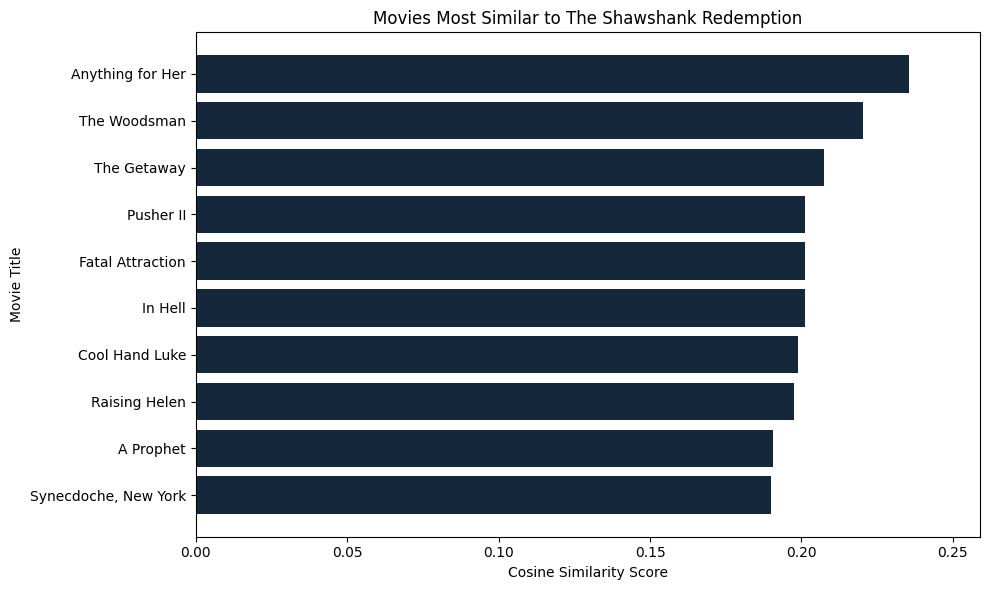

In [ ]:
top_matches = dist[1:11]
match_titles = [new_df.iloc[index].title for index,score in top_matches]
match_scores = [score for index,score in top_matches]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(match_titles[::-1],match_scores[::-1],color="#15283B")
ax.set_title(f"Movies Most Similar to {new_df.iloc[0].title}")
ax.set_xlabel("Cosine Similarity Score")
ax.set_ylabel("Movie Title")
ax.set_xlim(0,max(match_scores) * 1.1)
plt.tight_layout()
plt.show()

In [24]:
for i in dist[0:5]:
    print(new_df.iloc[i[0]].title)

The Shawshank Redemption
Anything for Her
The Woodsman
The Getaway
Pusher II


## **Recommendation Function**

In [25]:
def recommend(movies):
    index = new_df[new_df['title']==movies].index[0]
    distance = sorted(list(enumerate(sim[0])),reverse=True,key=lambda vec:vec[1])
    for i in distance[0:5]:
        print(new_df.iloc[i[0]].title)

In [26]:
recommend("Iron Man")

The Shawshank Redemption
Anything for Her
The Woodsman
The Getaway
Pusher II
